# 14 · Stability, trim and tail sizing inside the closure

The Halo's binding list ends with `static_margin` and `cn_beta_per_rad`: the tails are sized by stability. `controls/stability.py`
(143 lines) holds the equations: longitudinal neutral point, static margin and pitch trim; directional stability; rudder authority for a
failed propulsor. As always they are expressions only: the caller owns the trim variables (alpha, elevator) and the constraints.
`examples/tail_sizing.py` puts them inside the mass closure. This notebook goes through both.

**In this notebook**
1. Longitudinal: lift slopes, downwash, the neutral point and the static margin.
2. Pitch trim: the moment equation and the trim drag it costs.
3. Directional: Cn_beta from the fin and the fuselage; the rudder needed after a propulsor failure.
4. Tail sizing in one Opti: closure, hover trim, cruise trim, static margin, Cn_beta, rudder.
5. What the Halo uses: two margins, a hover-trim CG, and `TailTrim` for drag.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.controls.stability import (LongitudinalStability, DirectionalStability, flap_effectiveness,
                                                 failed_propulsor_yaw_moment_Nm)
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.vehicle.condition import StructuralDesignCondition
from examples.aircraft_mass_closure import build_reference_aircraft
aero = SimpleAerodynamics()
longitudinal, directional = LongitudinalStability(), DirectionalStability()

## 1. Neutral point and static margin

With wing and tail lift slopes $a_w$, $a_t$ (the aerodynamics model's analytic slopes), downwash gradient
$\partial\varepsilon/\partial\alpha = 2a_w/(\pi A)$, tail efficiency $\eta_t = 0.9$, and Raymer's destabilizing fuselage term
$C_{m\alpha,f}$:

$$x_\text{np} = \frac{a_w\,x_{ac,w} + \eta_t\frac{S_t}{S}a_t\big(1 - \frac{\partial\varepsilon}{\partial\alpha}\big)x_{ac,t}}{a_w + \eta_t\frac{S_t}{S}a_t\big(1 - \frac{\partial\varepsilon}{\partial\alpha}\big)} - \frac{C_{m\alpha,f}\,\bar c}{a_\text{total}},\qquad \mathrm{SM} = \frac{x_\text{np} - x_\text{cg}}{\bar c}$$

with aerodynamic centres at the quarter MAC (unswept surfaces).

    def neutral_point_x_m(self, aircraft, aerodynamics, velocity_m_s, altitude_m):
        chord_m, slope_wing, slope_tail, downwash_gradient, tail_volume_ratio, cm_alpha_fuselage = self._terms(
            aircraft, aerodynamics, velocity_m_s, altitude_m)
        tail_slope_effective = tail_volume_ratio * slope_tail * (1 - downwash_gradient)
        slope_total = slope_wing + tail_slope_effective
        return ((slope_wing * _quarter_mac_x_m(aircraft.wing)
                 + tail_slope_effective * _quarter_mac_x_m(aircraft.horizontal_tail)) / slope_total
                - cm_alpha_fuselage * chord_m / slope_total)



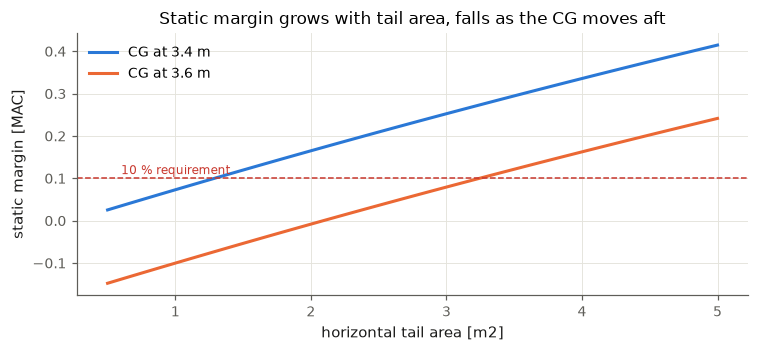

In [2]:
print(inspect.getsource(LongitudinalStability.neutral_point_x_m))
areas = onp.linspace(0.5, 5.0, 46)
fig, ax = plt.subplots(figsize=(7, 3.3))
for x_cg_m, color in ((3.4, blue), (3.6, orange)):
    margins = []
    for area_m2 in areas:
        aircraft = build_reference_aircraft(x_le_wing_m=3.2, area_horizontal_tail_m2=area_m2)
        margins.append(longitudinal.static_margin(aircraft, aero, x_cg_m, 60.0, 1000.0))
    ax.plot(areas, margins, color=color, lw=2, label=f"CG at {x_cg_m} m")
ax.axhline(0.10, color=red, ls="--", lw=1); ax.annotate("10 % requirement", (0.6, 0.11), fontsize=8, color=red)
ax.set(xlabel="horizontal tail area [m2]", ylabel="static margin [MAC]", title="Static margin grows with tail area, falls as the CG moves aft")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Pitch trim

`LongitudinalStability.evaluate(aircraft, aerodynamics, x_cg_m, velocity, altitude, alpha_deg, elevator_deg)` returns the moment coefficient
about the CG and the trimmed lift:

$$C_m = C_{m,ac,w} + C_{L,w}\frac{x_\text{cg} - x_{ac,w}}{\bar c} - \eta_t\frac{S_t}{S}\,C_{L,t}\,\frac{x_{ac,t} - x_\text{cg}}{\bar c} + C_{m\alpha,f}\,\alpha,$$

$$C_{L,t} = a_t\big(\alpha + i_t - \varepsilon + \tau_e\,\delta_e\big),\qquad \varepsilon = 2C_{L,w}/(\pi A)$$

with the plain-flap effectiveness $\tau_e$ from thin-airfoil theory (`flap_effectiveness`, × 0.8 viscous correction). It also returns the tail's
induced drag as a `DragIncrement`, which the caller adds to the wing aerodynamics (the hook of tutorial 13). The caller trims with two
equalities: $C_m = 0$ and trimmed lift = weight.

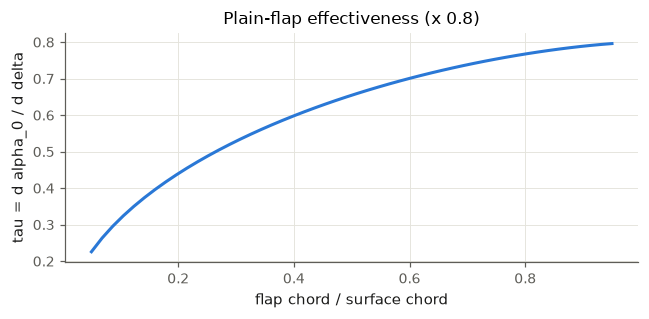

trimmed at alpha 3.44 deg, elevator -4.33 deg; wing CL 0.653, tail CL -0.105; trim drag dCD 0.00015
PASS  trim: Cm = 0 and lift = weight


In [3]:
fractions = onp.linspace(0.05, 0.95, 50)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(fractions, flap_effectiveness(fractions), color=blue, lw=2)
ax.set(xlabel="flap chord / surface chord", ylabel="tau = d alpha_0 / d delta", title="Plain-flap effectiveness (x 0.8)")
plt.tight_layout(); plt.show()

aircraft = build_reference_aircraft(x_le_wing_m=3.2, area_horizontal_tail_m2=2.16, area_vertical_tail_m2=1.92)
weight_N = 1555.0 * 9.80665
opti = asb.Opti()
alpha_deg = opti.variable(init_guess=3.0, lower_bound=-5, upper_bound=15)
elevator_deg = opti.variable(init_guess=-3.0, lower_bound=-30, upper_bound=30)
trim = longitudinal.evaluate(aircraft, aero, 3.52, 60.0, 1000.0, alpha_deg, elevator_deg)
opti.subject_to([trim.cm == 0, trim.lift_N / weight_N == 1])
s = opti.solve(verbose=False)
print(f"trimmed at alpha {s.value(alpha_deg):.2f} deg, elevator {s.value(elevator_deg):.2f} deg; wing CL {s.value(trim.cl_wing):.3f}, "
      f"tail CL {s.value(trim.cl_tail):+.3f}; trim drag dCD {s.value(trim.trim_drag.cd):.5f}")
check("trim: Cm = 0 and lift = weight", abs(s.value(trim.cm)) < 1e-9 and abs(s.value(trim.lift_N) - weight_N) < 1e-6)

## 3. Directional stability and rudder authority

$C_{n\beta}$ = fin contribution + fuselage (Raymer eq. 16.47):

$$C_{n\beta} = \eta_v\,a_v\,\frac{S_v\,l_v}{S\,b} - 1.3\,\frac{\mathcal V_\text{fus}}{S\,b}$$

with the fin slope evaluated at 1.55 × its geometric aspect ratio (end-plating by the fuselage and horizontal tail). The rudder needed to hold a
yaw moment $N$ is $\delta_r = N / (q S b\,\tau_r\,\eta_v a_v S_v l_v/(S b))$. The design case is a failed outboard propulsor at $1.2\,V_\text{stall}$:
its missing thrust (plus drag) at the wing-tip arm.

In [4]:
for area_m2 in (1.0, 1.92, 3.0):
    a_ = replace(aircraft, vertical_tail=replace(aircraft.vertical_tail, area_m2=area_m2))
    cn_beta = directional.cn_beta_per_rad(a_, aero, 3.52, 60.0, 1000.0)
    yaw_Nm = failed_propulsor_yaw_moment_Nm(thrust_per_propulsor_N=250.0, lateral_arm_m=a_.wing.span_m() / 2)
    rudder = directional.rudder_for_yaw_moment_deg(a_, aero, 3.52, 44.6, 0.0, yaw_Nm)
    print(f"fin {area_m2:4.2f} m2: Cn_beta {cn_beta:+.4f} /rad, rudder for a failed outboard rotor (250 N) at 44.6 m/s {rudder:5.1f} deg")

fin 1.00 m2: Cn_beta +0.0041 /rad, rudder for a failed outboard rotor (250 N) at 44.6 m/s  16.0 deg
fin 1.92 m2: Cn_beta +0.0603 /rad, rudder for a failed outboard rotor (250 N) at 44.6 m/s   8.1 deg
fin 3.00 m2: Cn_beta +0.1288 /rad, rudder for a failed outboard rotor (250 N) at 44.6 m/s   5.1 deg


## 4. Tail sizing inside the closure

`solve_tail_sizing`: minimum take-off mass over wing position and both tail areas, with three trim variables (cruise alpha and elevator, and
alpha at the minimum-control speed), subject to:

- mass closure and **hover pitch trim** (CG under the common rotor station: the tiltrotor's defining constraint on CG);
- cruise trim: $C_m = 0$, trimmed lift = weight, elevator within ±15°;
- static margin ≥ 10 % MAC; $C_{n\beta} \ge 0.06$ /rad;
- failed outboard rotor at $1.2\,V_\text{stall}$: rudder ≤ 20°, with level flight at that speed.

All limits are margins, so the report names what binds.

In [5]:
from examples.tail_sizing import solve_tail_sizing
print(inspect.getsource(solve_tail_sizing)[inspect.getsource(solve_tail_sizing).find("    opti = asb.Opti()"):][:3600])

    opti = asb.Opti()
    mass_takeoff_kg = opti.variable(init_guess=1550, lower_bound=100)
    x_le_wing_m = opti.variable(init_guess=3.2, lower_bound=0.5, upper_bound=5.5)
    area_horizontal_tail_m2 = opti.variable(init_guess=2.4, lower_bound=0.3)
    area_vertical_tail_m2 = opti.variable(init_guess=1.6, lower_bound=0.3)
    alpha_cruise_deg = opti.variable(init_guess=3.5, lower_bound=-5, upper_bound=20)
    elevator_cruise_deg = opti.variable(init_guess=-5, lower_bound=-30, upper_bound=30)
    alpha_minimum_control_deg = opti.variable(init_guess=8, lower_bound=-5, upper_bound=20)

    aircraft = build_reference_aircraft(x_le_wing_m, mass_payload_kg, count_rotors,
                                        area_horizontal_tail_m2, area_vertical_tail_m2)
    weight_N = mass_takeoff_kg * acceleration_gravity_m_s2
    # The fuselage correlation takes the untrimmed (wing) cruise L/D: the trimmed
    # value needs the CG, which needs the masses. Its exponent is -0.072, so the
    # differen

In [6]:
result = solve_tail_sizing()
print(f"MTOM {result.mass_takeoff_kg:.1f} kg; wing LE {result.x_le_wing_m:.3f} m; tails: horizontal {result.area_horizontal_tail_m2:.3f} m2, "
      f"vertical {result.area_vertical_tail_m2:.3f} m2")
print(f"static margin {result.static_margin:.3f}, Cn_beta {result.cn_beta_per_rad:.4f}, cruise alpha {result.alpha_cruise_deg:.2f} deg, "
      f"elevator {result.elevator_cruise_deg:.2f} deg, rudder {result.rudder_failed_rotor_deg:.2f} deg at {result.velocity_minimum_control_m_s:.1f} m/s")
print("margins, most critical first:")
for label, value in result.margins:
    print(f"   {value:+.4f}  {label}")
check("the horizontal tail is sized by the static margin", abs(dict(result.margins)["static_margin"]) < 1e-6)
binding_v = [l for l, v in result.margins if abs(v) < 1e-6 and l in ("cn_beta_per_rad", "rudder_failed_rotor_deg")]
check("the vertical tail is sized by Cn_beta or the failed-rotor rudder", len(binding_v) >= 1)

MTOM 1553.3 kg; wing LE 3.234 m; tails: horizontal 2.156 m2, vertical 1.916 m2
static margin 0.100, Cn_beta 0.0600, cruise alpha 3.52 deg, elevator -5.57 deg, rudder 14.06 deg at 44.6 m/s
margins, most critical first:
   -0.0000  cn_beta_per_rad
   -0.0000  static_margin
   +0.2968  rudder_failed_rotor_deg
   +0.6289  elevator_cruise_up_deg
   +0.7318  alpha_cruise_deg
   +1.3711  elevator_cruise_down_deg
PASS  the horizontal tail is sized by the static margin
PASS  the vertical tail is sized by Cn_beta or the failed-rotor rudder


Reading it: **hover trim fixes the CG** at the rotor station (the wing moves to put it there), so the static margin requirement sets where the
neutral point must be, which sets the horizontal tail. The fin is set by whichever of $C_{n\beta}$ and the rudder case is harder.

## 5. What the Halo uses

`solve_halo_sizing_once` keeps the two stability margins (evaluated at a fixed 80 m/s, 1,000 m condition) and the hover-trim CG:

In [7]:
import examples.halo_sizing as hs
source = inspect.getsource(hs.solve_halo_sizing_once)
for needle in ("static_margin = ", "cn_beta_per_rad = ", 'margin_above("static_margin"', 'margin_above("cn_beta_per_rad"', "x_cg_m == "):
    start = source.find(needle)
    line_start = source.rfind("\n", 0, start) + 1
    print(source[line_start:source.find("\n", start)].strip())

static_margin = longitudinal.static_margin(aircraft, aerodynamics, x_cg_m, 80.0, 1000.0)
cn_beta_per_rad = directional.cn_beta_per_rad(aircraft, aerodynamics, x_cg_m, 80.0, 1000.0)
margin_above("static_margin", static_margin, 0.10),
margin_above("cn_beta_per_rad", cn_beta_per_rad, 0.06),
x_cg_m == aircraft.wing.x_le_root_m + 0.25 * aircraft.wing.chord_root_m(),   # hover pitch trim


Cruise trim drag in the reference comes from `TailTrim` inside `BuildupAerodynamics` (tutorial 13) rather than from trim variables, and the Halo's
V-tail is represented by the tail dihedral (`angle_dihedral_tail_deg`). Conversion-corridor trim (ruddervator limits through the transition)
is checked after sizing, in `trajectory/` (see `docs/decisions/039`).

## Summary

- Neutral point from wing and tail slopes, downwash and the fuselage term; static margin in MAC; all expressions.
- Trim is two caller equalities ($C_m = 0$, lift = weight) on alpha and elevator; trim drag returns as a `DragIncrement`.
- $C_{n\beta}$ and the failed-rotor rudder size the fin; static margin sizes the horizontal tail; hover trim fixes the CG.
- In the Halo: static margin ≥ 0.10 and $C_{n\beta}$ ≥ 0.06 as margins, CG under the rotors, trim drag from `TailTrim`.

## Check yourself

<details><summary>1. Why does a tiltrotor's CG location come out of the problem rather than being chosen?</summary>

In hover with equal rotor thrusts the CG must sit under the rotor station (the hover pitch trim equality). The wing position (which carries the rotors) is a variable that satisfies it; the tails then provide the cruise stability around that CG.
</details>

<details><summary>2. A stability margin has a large multiplier in the Halo. What does that tell a configuration designer?</summary>

That requirement is expensive in take-off mass (tail area, plus everything that resizes around it). It is worth questioning the requirement (10 % static margin with fly-by-wire?) or the tail arm.
</details>

In [8]:
check_summary()

3 of 3 checks passed
